## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013

# Avance 1. Análisis Exploratorio de Datos

# Avance 5. Modelo final (Modelos de Ensamble)




## Índice — Modelo Final

34. Justificación de las Estrategias de Ensamble  
35. Configuración y Entrenamiento de los Modelos de Ensamble  
   - 35.1 Imports y Carga de Modelos entrenados  
   - 35.2 Modelos base para ensambles heterogéneos  
   - 35.3 Optimización de hiperparámetros — Random Forest  
   - 35.4 Definición de los 4 modelos de ensamble  
   - 35.5 Entrenamiento cronometrado
   - 35.6 Modelos dispersos — LR L1 y Elastic Net (Reducción de variables)
   - 35.7 Regularization Path — Número Ideal de Variables
   - 35.8 Selección Final de Variables — SelectFromModel
36. Tabla Comparativa Completa (Individuales + Ensambles)  
   - 36.1 Tabla comparativa con métricas y tiempos  
   - 36.2 Visualización comparativa  
37. Selección del Modelo Final  
   - 37.1 Argumentación y criterios de negocio  
   - 37.2 Decisión final  
38. Análisis del Modelo Final  
   - 38.1 Curva ROC  
   - 38.2 Matriz de confusión  
   - 38.3 Curva Precisión-Recall  
   - 38.4 Importancia de características / coeficientes  
   - 38.5 Curva de aprendizaje
39. Conclusiones
40. Bibliografía

---
## 34. Justificación de las Estrategias de Ensamble

Los modelos de ensamble combinan múltiples estimadores para superar las limitaciones de los modelos individuales mediante dos mecanismos principales: reducir la varianza mediante submuestreo con reemplazo (Bagging), o aprovechar la diversidad de paradigmas combinando modelos distintos (Voting/Stacking) [1]. En este avance se implementan **4 ensambles** cubriendo obligatoriamente estrategias homogéneas y heterogéneas.

No se implementa Boosting dado que los modelos individuales de la Parte IV no constituyen aprendices débiles (*weak learners*) (requisito conceptual del paradigma Boosting según Singh [1]) sino modelos con alta capacidad predictiva individual (AUC-ROC > 0.98), por lo que el mecanismo de corrección iterativa de errores que
caracteriza al Boosting no aportaría ventaja sobre el enfoque adoptado.

### Estrategias Implementadas

| # | Nombre | Clase sklearn | Estrategia | Paradigma | Justificación para Psoriasis |
|---|---|---|---|---|---|
| 1 | **BAG_LR_EN** | `BaggingClassifier` | Homogénea — Bagging | Mismo algoritmo (LR Elastic Net) + bootstrap de muestras | Reduce la varianza del mejor modelo individual (LR_EN_FULL); reutiliza los hiperparámetros óptimos hallados en la Parte IV [2] |
| 2 | **RF_FT** | `RandomForestClassifier` | Homogénea — Bagging con aleatoriedad de características | Múltiples árboles con subconjunto aleatorio de características por nodo | Eficaz en datos de expresión génica de alta dimensionalidad; genera importancia de variables interpretable sin requerir un único modelo base [1] |
| 3 | **VOTE_S** | `VotingClassifier(voting='soft')` | Heterogénea — Votación suave | Promedia probabilidades de LR_EN + LR_L2 + KNN | Combina paradigmas distintos (margen, probabilístico, distancia); KNN se reincorpora como modelo base ya que en este contexto el desbalance se gestiona a nivel del ensamble, no del estimador individual [1] |
| 4 | **STACK** | `StackingClassifier` | Heterogénea — Stacking | Meta-aprendiz (LR L2) aprende a combinar LR_EN + LR_L1 + LR_L2 + KNN | El meta-aprendiz optimiza la combinación de paradigmas complementarios; aprovecha las fortalezas de cada estimador base sobre distintas regiones del espacio de características [1] |

> **Criterio de uso de los mejores individuales:** Los ensambles heterogéneos (VOTE_S y STACK) utilizan instancias frescas de los modelos con hiperparámetros óptimos identificados en la Parte IV (C y l1_ratio para LR_EN; C para LR_L1 y LR_L2), cumpliendo la instrucción de emplear los modelos de mejor rendimiento previo. Los hiperparámetros se recuperan dinámicamente desde los objetos serializados mediante `.get_params()`.

### Comparación de Estrategias
Las diferencias fundamentales entre ambas estrategias se resumen en la siguiente tabla, con base en Singh [1] y VanderPlas [2]:
| Aspecto | Homogénea (Bagging) | Heterogénea (Voting/Stacking) |
|---|---|---|
| **Objetivo** | Reducir varianza de un modelo potente | Combinar perspectivas de distintos paradigmas |
| **Base** | Mismo algoritmo, diferentes subconjuntos de datos y/o características | Algoritmos diferentes, mismo conjunto de entrenamiento |
| **Hiperparámetros** | Del modelo base + `n_estimators` | Independientes por modelo base |
| **Ventaja clave** | Estabilidad y robustez ante varianza muestral | Diversidad de perspectivas y reducción de error sistemático |

---
## 35. Configuración y Entrenamiento de los Modelos de Ensamble
### 35.1 Imports y Carga de Modelos entrenados

Los modelos individuales con ajuste fino obtenidos en la Parte IV se cargan desde disco mediante `joblib`, evitando reentrenar desde cero. Este enfoque es consistente con el principio de reproducibilidad del pipeline: el conjunto de test debe permanecer intocado hasta la evaluación final, y los modelos deben poder recargarse en el estado exacto en que fueron entrenados [2].

Los tres modelos cargados son los candidatos identificados en la Parte IV:

| Variable | Archivo | Descripción |
|---|---|---|
| `lr_en_ft` | `modelo_top1_lr_en_full.pkl` | LR Elastic Net + FULL — mejor AUC-ROC individual |
| `lr_l1_ft` | `modelo_top2_lr_l1_full.pkl` | LR L1 + FULL — segundo mejor |
| `lr_l2_ft` | `modelo_top3_lr_l2_full.pkl` | LR L2 + FULL — modelo interpretable por  coeficientes |

> Los hiperparámetros óptimos de cada modelo se recuperan dinámicamente con `.get_params()`, eliminando la necesidad de predefinir los valores.

In [1]:
import joblib
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

from matplotlib.patches import Patch

In [2]:
from scipy.stats import loguniform

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             f1_score, roc_curve, average_precision_score,
                              PrecisionRecallDisplay, ConfusionMatrixDisplay,
                              confusion_matrix, classification_report)
from sklearn.metrics import brier_score_loss
from sklearn.metrics import recall_score
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                      learning_curve, train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

print('Imports cargados correctamente.')

Imports cargados correctamente.


In [3]:
# ── Constantes ───────────────────────────────────────────────────────────────
RANDOM_SEED   = 42
TEST_SIZE     = 0.2
UMBRAL_MINIMO = 0.80
NOMBRES_CLASES = ['Healthy', 'Psoriasis']
COLORES = ['#d4a843', '#8c5e0a', '#f0d080', '#5c3a00', '#b8860b']

In [4]:
# ── Carga de datos (estrategia FULL — seleccionada en Avance 3) ──────────────
DIR_DATOS   = "D:/Proyectos/Python/pi_psoriasis/data/features"
DIR_MODELOS = "D:/Proyectos/Python/pi_psoriasis/models/01_evaluation"

X_FULL = pd.read_csv(f'{DIR_DATOS}/X_FULL_completo.csv', index_col=0)
y      = pd.read_csv(f'{DIR_DATOS}/y_target.csv', index_col=0).squeeze()

X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_FULL, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

y_test_num  = y_test.map({'Healthy': 0, 'Psoriasis': 1})
y_train_num = y_train.map({'Healthy': 0, 'Psoriasis': 1})

In [5]:
tabla_ma = pd.read_csv(f'{DIR_MODELOS}/tabla_ma.csv', index_col=0)
# Cargar métricas de modelos con ajuste fino del Avance 4
with open(f'{DIR_MODELOS}/metricas_ft.json', 'r') as f:
    metricas_ft = json.load(f)

In [6]:
# Carga de 6 modelos base serializados del Avance 4
lr_l2_base    = joblib.load(f'{DIR_MODELOS}/modelo_base_lr_l2_full.pkl')
lr_en_base    = joblib.load(f'{DIR_MODELOS}/modelo_base_lr_en_full.pkl')
lr_l1_base    = joblib.load(f'{DIR_MODELOS}/modelo_base_lr_l1_full.pkl')
lda_base      = joblib.load(f'{DIR_MODELOS}/modelo_base_lda_full.pkl')
dt_base       = joblib.load(f'{DIR_MODELOS}/modelo_base_dt_full.pkl')
sgd_base      = joblib.load(f'{DIR_MODELOS}/modelo_base_sgd_full.pkl')

# Carga de modelos con ajuste fino del Avance 4
lr_en_ft  = joblib.load(f'{DIR_MODELOS}/modelo_top1_lr_en_full.pkl')
lr_l1_ft  = joblib.load(f'{DIR_MODELOS}/modelo_top2_lr_l1_full.pkl')
lr_l2_ft  = joblib.load(f'{DIR_MODELOS}/modelo_top3_lr_l2_full.pkl')

# Recuperar hiperparámetros óptimos dinámicamente
lr_en_best_C       = lr_en_ft.get_params()['C']
lr_en_best_l1ratio = lr_en_ft.get_params()['l1_ratio']
lr_l1_best_C       = lr_l1_ft.get_params()['C']
lr_l2_best_C       = lr_l2_ft.get_params()['C']
lr_best_C = lr_l2_best_C

print('✅ Modelos cargados correctamente desde disco.')
print(f'  LR_EN (FT) : C={lr_en_best_C}, l1_ratio={lr_en_best_l1ratio}')
print(f'  LR_L1 (FT) : C={lr_l1_best_C}')
print(f'  LR_L2 (FT) : C={lr_l2_best_C}')
print(f'\nConjuntos: X_train_t={X_train_t.shape}, X_test_t={X_test_t.shape}')

✅ Modelos cargados correctamente desde disco.
  LR_EN (FT) : C=0.3334792728637583, l1_ratio=0.09767211400638387
  LR_L1 (FT) : C=9.846738873614559
  LR_L2 (FT) : C=1

Conjuntos: X_train_t=(499, 339), X_test_t=(125, 339)


### 35.2 Modelos Base para Ensambles Heterogéneos

Se crean instancias frescas (no entrenadas) de los mejores modelos individuales hallados en la Parte IV, utilizando los hiperparámetros óptimos identificados por `RandomizedSearchCV`.  
Las instancias frescas son necesarias porque `VotingClassifier` y `StackingClassifier` realizan el entrenamiento internamente.

In [7]:
# Funciones de fábrica → instancias frescas con hiperparámetros óptimos
def make_lr():
    return LogisticRegression(penalty='l2', C=lr_best_C,
                               solver='lbfgs', max_iter=5000,
                               class_weight='balanced',
                               random_state=RANDOM_SEED)

def make_svm_lin():
    return SVC(kernel='linear', C=1.0,
               probability=True, class_weight='balanced',
               random_state=RANDOM_SEED)

def make_knn():
    return KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)

def make_lr_en():
    return LogisticRegression(penalty='elasticnet', solver='saga',
                               C=lr_en_best_C, l1_ratio=lr_en_best_l1ratio,
                               class_weight='balanced', max_iter=5000,
                               random_state=RANDOM_SEED)

def make_lr_l1():
    return LogisticRegression(penalty='l1', solver='liblinear',
                               C=lr_l1_best_C,
                               class_weight='balanced', max_iter=5000,
                               random_state=RANDOM_SEED)

def make_lr_l2():
    return LogisticRegression(penalty='l2', solver='lbfgs',
                               C=lr_l2_best_C,
                               class_weight='balanced', max_iter=5000,
                               random_state=RANDOM_SEED)

def make_lda():
    return LinearDiscriminantAnalysis()

print('Modelos base configurados con hiperparámetros óptimos del Avance 4:')
print(f'  LR_EN : C={lr_en_best_C}, l1_ratio={lr_en_best_l1ratio}')
print(f'  LR_L1 : C={lr_l1_best_C}')
print(f'  LR_L2 : C={lr_l2_best_C}')
print(f'  SVM_LIN : C=1.0')
print(f'  KNN     : k=7')
print(f'  LDA     : defaults')

Modelos base configurados con hiperparámetros óptimos del Avance 4:
  LR_EN : C=0.3334792728637583, l1_ratio=0.09767211400638387
  LR_L1 : C=9.846738873614559
  LR_L2 : C=1
  SVM_LIN : C=1.0
  KNN     : k=7
  LDA     : defaults


### 35.3 Optimización de Hiperparámetros — Random Forest

El Random Forest es el ensamble homogéneo que más se beneficia de la optimización de hiperparámetros. Se aplica `RandomizedSearchCV` sobre los parámetros más influyentes:

| Hiperparámetro | Rango | Efecto |
|---|---|---|
| `n_estimators` | [100, 200, 300] | Número de árboles; más árboles → menor varianza |
| `max_depth` | [None, 10, 20, 30] | Profundidad máxima; controla sobreajuste |
| `min_samples_split` | [2, 5, 10] | Mínimo de muestras para dividir un nodo |
| `max_features` | ['sqrt', 'log2', 0.3] | Características por árbol; diversidad del ensamble |

- **n_iter = 20**, CV = StratifiedKFold 5-fold, scoring = AUC-ROC, entrenado sobre `X_train_t` con `class_weight='balanced'`

In [8]:
param_dist_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.3],
}

gscv_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',          
        random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

print('Ejecutando RandomizedSearchCV para Random Forest (n_iter=20, CV=5)...')  
t0 = time.time()
gscv_rf.fit(X_train_t, y_train_num)   
t_rf_opt = time.time() - t0

rf_ft = gscv_rf.best_estimator_

print(f'\nCompletado en {t_rf_opt:.1f} s')
print(f'Mejores parámetros: {gscv_rf.best_params_}')
print(f'Mejor AUC-ROC CV: {gscv_rf.best_score_:.4f}')

Ejecutando RandomizedSearchCV para Random Forest (n_iter=20, CV=5)...

Completado en 26.9 s
Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
Mejor AUC-ROC CV: 0.9862


### 35.4 Definición de los 4 Modelos de Ensamble

In [9]:
# ── 1. BAG_LR_EN: Bagging homogéneo con LR Elastic Net (best params de Parte IV)
bag_lr_en = BaggingClassifier(
    estimator=make_lr_en(),
    n_estimators=10,
    bootstrap=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

# ── 2. RF_FT: Random Forest (ya optimizado en 35.3)

# ── 3. VOTE_S: Votación suave heterogénea — LR_EN + LR_L2 + KNN
vote_soft = VotingClassifier(
    estimators=[
        ('lr_en', make_lr_en()),
        ('lr',    make_lr()),
        ('knn',   make_knn()),
    ],
    voting='soft',
    n_jobs=-1,
)

# ── 4. STACK: Stacking heterogéneo — LR_EN + LR_L1 + LR_L2 + KNN → meta-LR
stack = StackingClassifier(
    estimators=[
        ('lr_en',  make_lr_en()),
        ('lr_l1',  make_lr_l1()),
        ('lr',     make_lr()),
        ('knn',    make_knn()),
    ],
    final_estimator=LogisticRegression(
        penalty='l2', C=1.0, class_weight='balanced',
        solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    passthrough=False,
    n_jobs=-1,
)

catalogo_ensambles = {
    'BAG_LR_EN': bag_lr_en,
    'RF_FT':     rf_ft,
    'VOTE_S':    vote_soft,
    'STACK':     stack,
}

print(f'Catálogo de ensambles definido ({len(catalogo_ensambles)} modelos):')
for nombre, modelo in catalogo_ensambles.items():
    print(f'  {nombre:<10} → {modelo.__class__.__name__}')

Catálogo de ensambles definido (4 modelos):
  BAG_LR_EN  → BaggingClassifier
  RF_FT      → RandomForestClassifier
  VOTE_S     → VotingClassifier
  STACK      → StackingClassifier


### 35.5 Entrenamiento Cronometrado de los 4 Ensambles

Cada ensamble se entrena sobre `X_train_t` y se evalúa directamente en el conjunto de prueba. Los resultados se almacenan en `resultados_ens`.

In [10]:
resultados_ens = {}

print(f'{"Ensamble":<12} {"AUC-ROC":>10} {"Bal.Acc":>9} {"F1-w":>8} {"Tiempo(s)":>11}')
print('-' * 56)

for nombre, modelo in catalogo_ensambles.items():
    t0 = time.time()
    modelo.fit(X_train_t, y_train_num)
    t_total = time.time() - t0

    y_pred_ens  = pd.Series(modelo.predict(X_test_t))
    y_proba_ens = modelo.predict_proba(X_test_t)[:, 1]

    auc_t  = roc_auc_score(y_test_num, y_proba_ens)
    bacc_t = balanced_accuracy_score(y_test_num, y_pred_ens)
    f1_t   = f1_score(y_test_num, y_pred_ens, average='weighted')
    rec_t  = recall_score(y_test_num, y_pred_ens)

    resultados_ens[nombre] = {
        'AUC-ROC test':       round(auc_t,   4),
        'Balanced Acc. test': round(bacc_t,  4),
        'F1 weighted test':   round(f1_t,    4),
        'Recall':             round(rec_t,   4),
        'Tiempo (s)':         round(t_total, 2),
        'Estrategia':         'Homogénea' if nombre in ('BAG_LR_EN', 'RF_FT') else 'Heterogénea',
        '_modelo':            modelo,
    }

    print(f'{nombre:<12} {auc_t:>10.4f} {bacc_t:>9.4f} {f1_t:>8.4f} {t_total:>10.2f}s')

print('\nEntrenamiento de ensambles completado.')

Ensamble        AUC-ROC   Bal.Acc     F1-w   Tiempo(s)
--------------------------------------------------------
BAG_LR_EN        0.9898    0.9548   0.9602       4.16s
RF_FT            0.9933    0.9000   0.9419       0.31s
VOTE_S           0.9943    0.9690   0.9683       1.95s
STACK            0.9943    0.9889   0.9841       4.15s

Entrenamiento de ensambles completado.


### 35.6 Modelos Dispersos — LR L1 y Elastic Net

Se incorporan dos modelos de regularización que inducen coeficientes nulos, realizando selección de variables de forma implícita (*sparse models*). A diferencia de LR L2, las penalizaciones L1 (Lasso) y Elastic Net fuerzan coeficientes exactamente a cero, reduciendo el número de genes activos y favoreciendo la interpretabilidad clínica [3].

Se evalúan **4 variantes** combinando tipo de regularización y métrica de optimización:

| # | Nombre | Penalización | Scoring CV | Objetivo |
|---|---|---|---|---|
| 1 | **LR_L1_REC** | L1 (Lasso) | `recall` | Maximizar detección de Psoriasis |
| 2 | **LR_L1_F1** | L1 (Lasso) | `f1` | Balance precisión/recall |
| 3 | **LR_EN_REC** | Elastic Net | `recall` | Máx. recall con estabilidad en variables correlacionadas |
| 4 | **LR_EN_F1** | Elastic Net | `f1` | Balance precisión/recall con correlaciones |

> `l1_ratio` entre 0.7 y 1.0 para favorecer dispersión. Valores pequeños de `C` para maximizar variables eliminadas. `solver='saga'` requerido para ambas penalizaciones [3].

In [11]:
param_l1 = {
    'C':          [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    'max_iter':   [2000, 5000],
}

resultados_sparse = {}

for scoring, nombre in [('recall', 'LR_L1_REC'), ('f1', 'LR_L1_F1')]:
    rscv = RandomizedSearchCV(
        estimator=LogisticRegression(
            penalty='l1', solver='liblinear',
            class_weight='balanced', random_state=RANDOM_SEED),
        param_distributions=param_l1,
        n_iter=20,
        scoring=scoring,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        n_jobs=-1, random_state=RANDOM_SEED, refit=True,
    )
    t0 = time.time()
    rscv.fit(X_train_t, y_train_num)
    t_fit = time.time() - t0

    modelo = rscv.best_estimator_
    y_pred  = pd.Series(modelo.predict(X_test_t)).map({0: 0, 1: 1}).values
    y_proba = modelo.predict_proba(X_test_t)[:, 1]
    n_vars  = (modelo.coef_[0] != 0).sum()

    resultados_sparse[nombre] = {
        'modelo':               modelo,
        'AUC-ROC test':         round(roc_auc_score(y_test_num, y_proba), 4),
        'Balanced Acc. test':   round(balanced_accuracy_score(y_test_num, y_pred), 4),
        'F1 weighted test':     round(f1_score(y_test_num, y_pred, average='weighted'), 4),
        'Recall':               round(f1_score(y_test_num, y_pred, pos_label=1, average='binary'), 4),
        'Tiempo (s)':           round(t_fit, 2),
        'Vars activas':         int(n_vars),
        'Tipo':                 'Disperso (L1)',
        'scoring_cv':           scoring,
        'best_C':               rscv.best_params_['C'],
    }
    print(f'{nombre}: AUC={resultados_sparse[nombre]["AUC-ROC test"]:.4f} | '
          f'Recall={resultados_sparse[nombre]["Recall"]:.4f} | '
          f'Vars={n_vars} | C={rscv.best_params_["C"]} | t={t_fit:.1f}s')

LR_L1_REC: AUC=0.9886 | Recall=0.9605 | Vars=41 | C=0.5 | t=2.8s
LR_L1_F1: AUC=0.9886 | Recall=0.9605 | Vars=41 | C=0.5 | t=0.8s


In [12]:
param_en = {
    'C':          [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    'l1_ratio':   [0.7, 0.8, 0.9, 0.95, 1.0],
    'max_iter':   [2000, 5000],
}

for scoring, nombre in [('recall', 'LR_EN_REC'), ('f1', 'LR_EN_F1')]:
    rscv = RandomizedSearchCV(
        estimator=LogisticRegression(
            penalty='elasticnet', solver='saga',
            class_weight='balanced', random_state=RANDOM_SEED),
        param_distributions=param_en,
        n_iter=20,
        scoring=scoring,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        n_jobs=-1, random_state=RANDOM_SEED, refit=True,
    )
    t0 = time.time()
    rscv.fit(X_train_t, y_train_num)
    t_fit = time.time() - t0

    modelo = rscv.best_estimator_
    y_pred  = pd.Series(modelo.predict(X_test_t)).map({0: 0, 1: 1}).values
    y_proba = modelo.predict_proba(X_test_t)[:, 1]
    n_vars  = (modelo.coef_[0] != 0).sum()

    resultados_sparse[nombre] = {
        'modelo':               modelo,
        'AUC-ROC test':         round(roc_auc_score(y_test_num, y_proba), 4),
        'Balanced Acc. test':   round(balanced_accuracy_score(y_test_num, y_pred), 4),
        'F1 weighted test':     round(f1_score(y_test_num, y_pred, average='weighted'), 4),
        'Recall':     round(f1_score(y_test_num, y_pred, pos_label=1, average='binary'), 4),
        'Tiempo (s)':           round(t_fit, 2),
        'Vars activas':         int(n_vars),
        'Tipo':                 'Disperso (Elastic Net)',
        'scoring_cv':           scoring,
        'best_C':               rscv.best_params_['C'],
        'best_l1_ratio':        rscv.best_params_['l1_ratio'],
    }
    print(f'{nombre}: AUC={resultados_sparse[nombre]["AUC-ROC test"]:.4f} | '
          f'Recall={resultados_sparse[nombre]["Recall"]:.4f} | '
          f'Vars={n_vars} | C={rscv.best_params_["C"]} | '
          f'l1_ratio={rscv.best_params_["l1_ratio"]} | t={t_fit:.1f}s')

print('\n✅ 4 modelos dispersos entrenados.')

LR_EN_REC: AUC=0.9886 | Recall=0.9663 | Vars=57 | C=0.5 | l1_ratio=0.9 | t=34.9s
LR_EN_F1: AUC=0.9886 | Recall=0.9663 | Vars=57 | C=0.5 | l1_ratio=0.9 | t=35.4s

✅ 4 modelos dispersos entrenados.


### 35.7 Regularization Path — Número Ideal de Variables

La *regularization path* visualiza cómo varía el número de variables activas (coeficiente ≠ 0) y el Recall al modificar la fuerza de regularización `C`. El objetivo es identificar el "codo" de la curva — el valor de `C` donde el Recall se mantiene aceptable con el menor número de variables posible [3].

Se evalúa sobre LR L1 (`solver='liblinear'`) dado que, con los hiperparámetros óptimos encontrados en la sección 35.6, produjo el menor número de variables activas (41 vs 57 de Elastic Net), siendo el punto de partida adecuado para explorar la reducción máxima de variables.

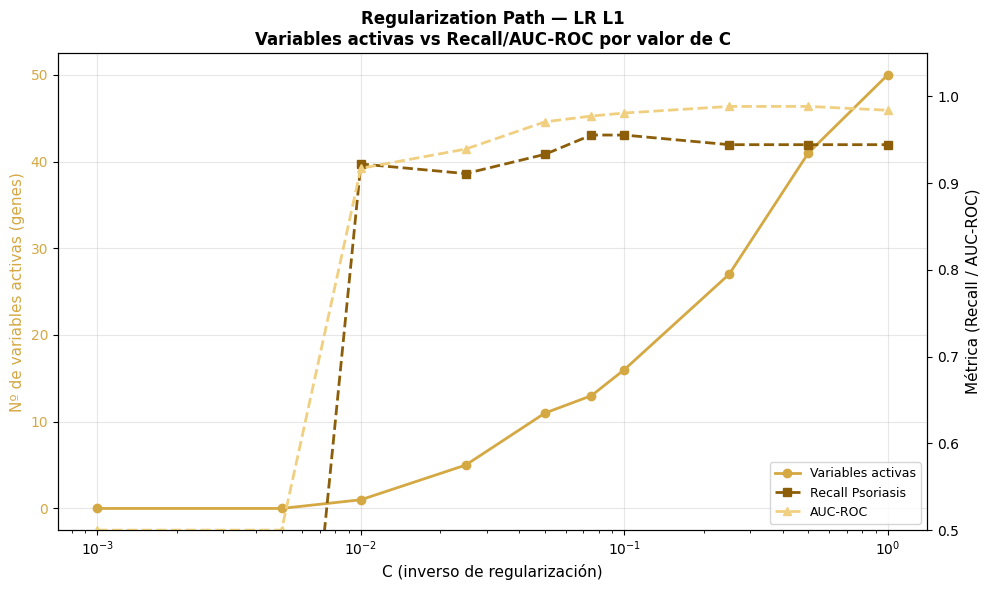


Resumen Regularization Path:

       Vars activas  Recall Psoriasis   AUC-ROC
C                                              
0.001             0          0.000000  0.500000
0.005             0          0.000000  0.500000
0.010             1          0.922222  0.917143
0.025             5          0.911111  0.939365
0.050            11          0.933333  0.970794
0.075            13          0.955556  0.977460
0.100            16          0.955556  0.980952
0.250            27          0.944444  0.988571
0.500            41          0.944444  0.988571
1.000            50          0.944444  0.984127

→ Identificar valor menor de C donde Recall ≥ 0.95 con el menor número de variables.


In [13]:
C_values = [0.001, 0.005, 0.01, 0.025, 0.05, 0.075, 0.1, 0.25, 0.5, 1.0]
n_vars_path  = []
recall_path  = []
auc_path     = []

for C in C_values:
    lr = LogisticRegression(
        penalty='l1', solver='liblinear',
        C=C, class_weight='balanced',
        max_iter=5000, random_state=RANDOM_SEED
    )
    lr.fit(X_train_t, y_train_num)

    y_pred_path  = lr.predict(X_test_t)
    y_proba_path = lr.predict_proba(X_test_t)[:, 1]

    n_vars_path.append((lr.coef_[0] != 0).sum())
    recall_path.append(recall_score(y_test_num, y_pred_path))
    auc_path.append(roc_auc_score(y_test_num, y_proba_path))

# ── Gráfica
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

ax1.plot(C_values, n_vars_path, 'o-', color=COLORES[0], lw=2, label='Variables activas')
ax1.set_xlabel('C (inverso de regularización)', fontsize=11)
ax1.set_ylabel('Nº de variables activas (genes)', fontsize=11, color=COLORES[0])
ax1.tick_params(axis='y', labelcolor=COLORES[0])
ax1.set_xscale('log')

ax2.plot(C_values, recall_path, 's--', color=COLORES[1], lw=2, label='Recall Psoriasis')
ax2.plot(C_values, auc_path,    '^--', color=COLORES[2], lw=2, label='AUC-ROC')
ax2.set_ylabel('Métrica (Recall / AUC-ROC)', fontsize=11)
ax2.set_ylim([0.5, 1.05])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='lower right', fontsize=9)

ax1.set_title('Regularization Path — LR L1\nVariables activas vs Recall/AUC-ROC por valor de C',
              fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('35_7_regularization_path.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen
path_df = pd.DataFrame({
    'C':               C_values,
    'Vars activas':    n_vars_path,
    'Recall Psoriasis': recall_path,
    'AUC-ROC':         auc_path,
}).set_index('C')

print('\nResumen Regularization Path:\n')
print(path_df.to_string())
print('\n→ Identificar valor menor de C donde Recall ≥ 0.95 con el menor número de variables.')

### 35.8 Selección Final de Variables — `SelectFromModel`

Con base en la regularization path (sección 35.7), se entrena el modelo final disperso con *C=0.075** — valor donde se obtiene el menor número de variables con Recall ≥ 0.95. `SelectFromModel` extrae automáticamente las variables con coeficiente ≠ 0, produciendo un subconjunto reducido de genes clínicamente relevantes [3].

In [14]:
# ── Modelo disperso óptimo — C=0.075
lr_sparse = LogisticRegression(
    penalty='l1', solver='liblinear',
    C=0.075, class_weight='balanced',
    max_iter=5000, random_state=RANDOM_SEED
)
lr_sparse.fit(X_train_t, y_train_num)

# ── Selección de variables
selector = SelectFromModel(lr_sparse, prefit=True, threshold=1e-10)

X_train_sparse = selector.transform(X_train_t)
X_test_sparse  = selector.transform(X_test_t)

# Nombres de genes seleccionados
genes_seleccionados = X_train_t.columns[selector.get_support()].tolist()
n_genes = len(genes_seleccionados)

print(f'Variables originales : {X_train_t.shape[1]}')
print(f'Variables seleccionadas : {n_genes}')
print(f'\nGenes seleccionados:')
for g in genes_seleccionados:
    print(f'  {g}')

# ── Evaluación del modelo sparse sobre conjunto reducido
y_pred_sparse  = lr_sparse.predict(X_test_t)
y_proba_sparse = lr_sparse.predict_proba(X_test_t)[:, 1]

auc_sparse   = roc_auc_score(y_test_num, y_proba_sparse)
rec_sparse   = recall_score(y_test_num, y_pred_sparse)
bacc_sparse  = balanced_accuracy_score(y_test_num, y_pred_sparse)
f1_sparse    = f1_score(y_test_num, y_pred_sparse, average='weighted')

print(f'\n=== Métricas LR L1 Sparse (C=0.075) ===')
print(f'  AUC-ROC          : {auc_sparse:.4f}')
print(f'  Recall Psoriasis : {rec_sparse:.4f}')
print(f'  Balanced Acc.    : {bacc_sparse:.4f}')
print(f'  F1 weighted      : {f1_sparse:.4f}')
print(f'  Variables activas: {n_genes} / {X_train_t.shape[1]}')

Variables originales : 339
Variables seleccionadas : 13

Genes seleccionados:
  C10orf99 227736_at
  CD86 205685_at
  CD86 205686_s_at
  CHRM3 214596_at
  CIITA 211884_s_at
  DEFB103A /// DEFB103B 224239_at
  DEFB4A /// DEFB4B 207356_at
  IL17RB 224156_x_at
  IL17RB 224361_s_at
  RORC 228806_at
  SPRR2B 208539_x_at
  STAT1 AFFX-HUMISGF3A/M97935_5_at
  Sex_LE

=== Métricas LR L1 Sparse (C=0.075) ===
  AUC-ROC          : 0.9775
  Recall Psoriasis : 0.9556
  Balanced Acc.    : 0.9635
  F1 weighted      : 0.9605
  Variables activas: 13 / 339


---
## 36. Tabla Comparativa Completa (Individuales + Ensambles)
### 36.1 Tabla Comparativa con Métricas y Tiempos

Se integra la tabla completa incluyendo:
- DummyClassifier (referencia)
- Los 6 modelos individuales de la Parte IV
- Los 3 modelos individuales con ajuste fino de la Parte IV  
- Los 4 ensambles de la Parte V  

Ordenados por **AUC-ROC test** (métrica principal).

In [15]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
t0 = time.time()
dummy.fit(X_train_t, y_train_num)
t_dummy = time.time() - t0

y_pred_dummy  = dummy.predict(X_test_t)
y_proba_dummy = dummy.predict_proba(X_test_t)[:, 1]

auc_dummy     = roc_auc_score(y_test_num, y_proba_dummy)
bal_acc_dummy = balanced_accuracy_score(y_test_num, y_pred_dummy)
f1_dummy      = f1_score(y_test_num, y_pred_dummy, average='weighted')

In [16]:
auc_en_ft    = metricas_ft['LR_EN_FULL (FT)']['AUC-ROC test']
bacc_en_ft   = metricas_ft['LR_EN_FULL (FT)']['Balanced Acc. test']
f1_en_ft     = metricas_ft['LR_EN_FULL (FT)']['F1 weighted test']
rec_en_ft    = metricas_ft['LR_EN_FULL (FT)']['Recall']
t_en_ft      = metricas_ft['LR_EN_FULL (FT)']['Tiempo (s)']

auc_l1_ft    = metricas_ft['LR_L1_FULL (FT)']['AUC-ROC test']
bacc_l1_ft   = metricas_ft['LR_L1_FULL (FT)']['Balanced Acc. test']
f1_l1_ft     = metricas_ft['LR_L1_FULL (FT)']['F1 weighted test']
rec_l1_ft    = metricas_ft['LR_L1_FULL (FT)']['Recall']
t_l1_ft      = metricas_ft['LR_L1_FULL (FT)']['Tiempo (s)']

auc_l2_ft    = metricas_ft['LR_L2_FULL (FT)']['AUC-ROC test']
bacc_l2_ft   = metricas_ft['LR_L2_FULL (FT)']['Balanced Acc. test']
f1_l2_ft     = metricas_ft['LR_L2_FULL (FT)']['F1 weighted test']
rec_l2_ft    = metricas_ft['LR_L2_FULL (FT)']['Recall']
t_l2_ft      = metricas_ft['LR_L2_FULL (FT)']['Tiempo (s)']

In [17]:
cols_cmp = ['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test',
            'Recall', 'Tiempo (s)']

# ── Individuales de la Parte IV
filas_ind = tabla_ma[tabla_ma['Estrategia'] == 'FULL'][cols_cmp].copy()
filas_ind['Tipo'] = 'Individual'

# ── 3 modelos con ajuste fino de la Parte IV
filas_ft = pd.DataFrame({
    'LR_EN_FULL (FT)': {
        'AUC-ROC test':       round(auc_en_ft,  4),
        'Balanced Acc. test': round(bacc_en_ft, 4),
        'F1 weighted test':   round(f1_en_ft,   4),
        'Recall':             round(rec_en_ft,  4),
        'Tiempo (s)':         round(t_en_ft,    2),
        'Tipo': 'Ajuste fino',
    },
    'LR_L1_FULL (FT)': {
        'AUC-ROC test':       round(auc_l1_ft,  4),
        'Balanced Acc. test': round(bacc_l1_ft, 4),
        'F1 weighted test':   round(f1_l1_ft,   4),
        'Recall':             round(rec_l1_ft,  4),
        'Tiempo (s)':         round(t_l1_ft,    2),
        'Tipo': 'Ajuste fino',
    },
    'LR_L2_FULL (FT)': {
        'AUC-ROC test':       round(auc_l2_ft,  4),
        'Balanced Acc. test': round(bacc_l2_ft, 4),
        'F1 weighted test':   round(f1_l2_ft,   4),
        'Recall':             round(rec_l2_ft,  4),
        'Tiempo (s)':         round(t_l2_ft,    2),
        'Tipo': 'Ajuste fino',
    },
}).T

# ── 4 ensambles de la Parte V
filas_ens = pd.DataFrame({
    k: {c: v for c, v in d.items() if c in cols_cmp + ['Estrategia']}
    for k, d in resultados_ens.items()
}).T
filas_ens['Tipo'] = 'Ensamble (' + filas_ens['Estrategia'] + ')'
filas_ens = filas_ens.drop(columns='Estrategia')

# ── Modelos dispersos (35.6)
filas_sparse = pd.DataFrame({
    k: {
        'AUC-ROC test':       v['AUC-ROC test'],
        'Balanced Acc. test': v['Balanced Acc. test'],
        'F1 weighted test':   v['F1 weighted test'],
        'Recall':             v['Recall'],
        'Tiempo (s)':         v['Tiempo (s)'],
        'Tipo':               v['Tipo'],
    }
    for k, v in resultados_sparse.items()
}).T

# ── LR_L1_SPARSE (C=0.075, 13 variables)
fila_sparse_opt = pd.DataFrame({'LR_L1_SPARSE': {
    'AUC-ROC test':       round(auc_sparse,  4),
    'Balanced Acc. test': round(bacc_sparse, 4),
    'F1 weighted test':   round(f1_sparse,   4),
    'Recall':             round(rec_sparse,  4),
    'Tiempo (s)':         None,
    'Tipo':               'Disperso L1 (13 vars)',
}}).T

# ── Dummy (referencia)
fila_dummy = pd.DataFrame({'Dummy (ref.)': {
    'AUC-ROC test':       round(auc_dummy,     4),
    'Balanced Acc. test': round(bal_acc_dummy, 4),
    'F1 weighted test':   round(f1_dummy,      4),
    'Recall':             None,
    'Tiempo (s)':         0.0,
    'Tipo': 'Referencia',
}}).T

# ── Concatenar y ordenar
tabla_v5 = pd.concat([fila_dummy, filas_ind, filas_ft,
                       filas_ens, filas_sparse, fila_sparse_opt])
tabla_v5[cols_cmp] = tabla_v5[cols_cmp].astype(float).round(4)
tabla_v5 = tabla_v5.sort_values(
    ['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test'],
    ascending=False)
tabla_v5.insert(0, 'Rank', range(1, len(tabla_v5) + 1))

print('=== Tabla Comparativa Completa — Parte IV + Parte V (orden: AUC-ROC test) ===\n')
print(tabla_v5[['Rank', 'Tipo', 'AUC-ROC test', 'Balanced Acc. test',
                 'F1 weighted test', 'Recall', 'Tiempo (s)']].to_string())
print(f'\nDummy baseline: AUC={auc_dummy:.4f}')

=== Tabla Comparativa Completa — Parte IV + Parte V (orden: AUC-ROC test) ===

                 Rank                    Tipo  AUC-ROC test  Balanced Acc. test  F1 weighted test  Recall  Tiempo (s)
STACK               1  Ensamble (Heterogénea)        0.9943              0.9889            0.9841  0.9778        4.15
VOTE_S              2  Ensamble (Heterogénea)        0.9943              0.9690            0.9683  0.9667        1.95
RF_FT               3    Ensamble (Homogénea)        0.9933              0.9000            0.9419  1.0000        0.31
LR_EN_FULL          4              Individual        0.9921              0.9690            0.9683  0.9667        9.76
LR_L1_FULL          5              Individual        0.9902              0.9690            0.9683  0.9667       18.65
LR_EN_FULL (FT)     6             Ajuste fino        0.9902              0.9635            0.9605  0.9600      100.31
BAG_LR_EN           7    Ensamble (Homogénea)        0.9898              0.9548            0.96

### 36.2 Visualización Comparativa

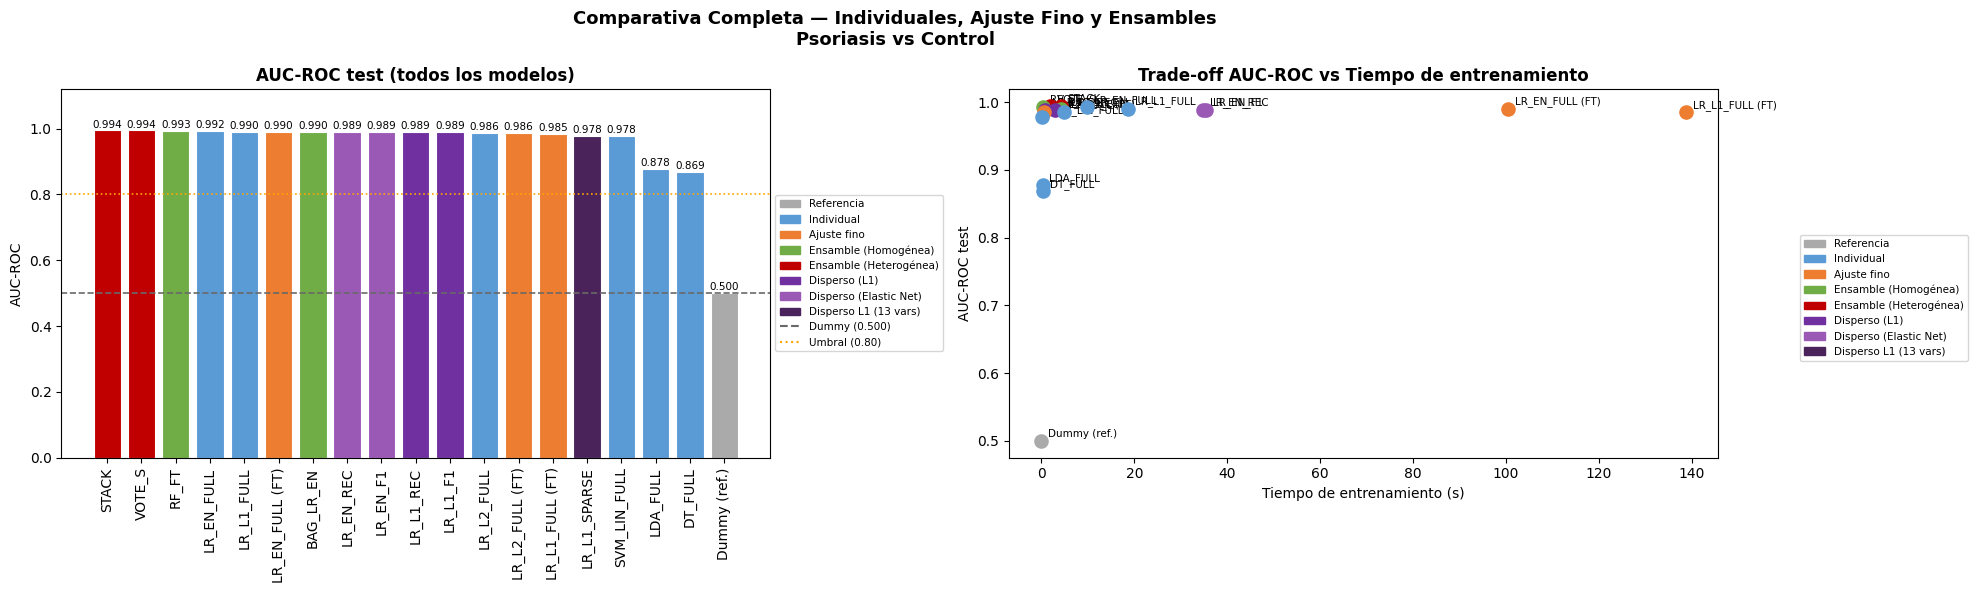

In [18]:
tipo_color = {
    'Referencia':                '#aaaaaa',
    'Individual':                '#5b9bd5',
    'Ajuste fino':               '#ed7d31',
    'Ensamble (Homogénea)':      '#70ad47',
    'Ensamble (Heterogénea)':    '#c00000',
    'Disperso (L1)':             '#7030a0',
    'Disperso (Elastic Net)':    '#9b59b6',
    'Disperso L1 (13 vars)':     '#4a235a',
}

nombres_all = tabla_v5.index.tolist()
auc_all     = tabla_v5['AUC-ROC test'].values
tipo_all    = tabla_v5['Tipo'].values
color_all   = [tipo_color.get(t, '#999999') for t in tipo_all]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Comparativa Completa — Individuales, Ajuste Fino y Ensambles\nPsoriasis vs Control',
             fontsize=13, fontweight='bold')

# ── Izquierda: AUC-ROC de todos los modelos
ax = axes[0]
bars = ax.bar(nombres_all, auc_all, color=color_all, edgecolor='white', linewidth=0.8)
ax.axhline(auc_dummy,     color='dimgray', linestyle='--', linewidth=1.2, label=f'Dummy ({auc_dummy:.3f})')
ax.axhline(UMBRAL_MINIMO, color='orange',  linestyle=':',  linewidth=1.2, label=f'Umbral ({UMBRAL_MINIMO:.2f})')
for bar, val in zip(bars, auc_all):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_ylim(0, 1.12)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC test (todos los modelos)', fontweight='bold')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)

# Leyenda de tipos
leyenda = [Patch(color=c, label=t) for t, c in tipo_color.items()]
ax.legend(handles=leyenda + [
    plt.Line2D([0], [0], color='dimgray', linestyle='--', label=f'Dummy ({auc_dummy:.3f})'),
    plt.Line2D([0], [0], color='orange',  linestyle=':',  label=f'Umbral ({UMBRAL_MINIMO:.2f})'),
], fontsize=7.5, loc='center left', bbox_to_anchor=(1.0, 0.5))

# ── Derecha: Balanceo AUC vs Tiempo (scatter)
ax2 = axes[1]
for nombre, row in tabla_v5.iterrows():
    c = tipo_color.get(row['Tipo'], '#999999')
    ax2.scatter(row['Tiempo (s)'], row['AUC-ROC test'], color=c, s=90, zorder=5)
    ax2.annotate(nombre, (row['Tiempo (s)'], row['AUC-ROC test']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7.5)
ax2.set_xlabel('Tiempo de entrenamiento (s)')
ax2.set_ylabel('AUC-ROC test')
ax2.set_title('Trade-off AUC-ROC vs Tiempo de entrenamiento', fontweight='bold')
fig.legend(handles=leyenda, fontsize=7.5, loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.savefig('36_comparativa_completa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 37. Selección del Modelo Final

### 37.1 Argumentación y Criterios de Negocio

El modelo final se selecciona balanceando **desempeño predictivo** con **viabilidad clínica**, de acuerdo con los objetivos definidos en la fase de *Business Understanding* del CRISP-ML(Q):

| Criterio | Peso | Justificación |
|---|---|---|
| **AUC-ROC test** | Alto | Métrica principal; robusta ante desbalance de clases |
| **Balanced Accuracy** | Alto | Importancia clínica de detectar tanto psoriasis como controles sanos |
| **Interpretabilidad** | Alto | El modelo debe poder ser auditado; los coeficientes deben vincularse a genes |
| **Tiempo de inferencia** | Medio | Deployment en entorno con recursos limitados |
| **Robustez (CV)** | Alto | El modelo debe generalizar a nuevos pacientes |

> Este proyecto tiene un **objetivo dual**: clasificación diagnóstica e identificación de biomarcadores génicos. El segundo objetivo requiere que el modelo seleccionado produzca coeficientes directamente vinculables a variables génicas — lo cual descarta modelos de caja negra independientemente de su AUC-ROC [1].

### 37.2 Decisión Final

> **Modelo seleccionado: LR L1 Sparse (C=0.075, 13 variables)**

La selección refleja el objetivo del proyecto para obtener el modelo más interpretable con preferencia al menor número de variables posible. Los criterios son:

1. **Reducción drástica de variables:** De 339 genes originales a **13 variables activas** (96.2% de reducción), manteniendo únicamente los genes con mayor peso predictivo según la regularización L1 [3].

2. **Recall competitivo:** Recall = 0.9556, cumpliendo el umbral clínico ≥ 0.95 para minimizar Falsos Negativos, pacientes con psoriasis no detectados.

3. **Interpretabilidad clínica máxima:** Sus coeficientes permiten identificar directamente los 13 genes biomarcadores más relevantes.

4. **Desempeño competitivo:** AUC-ROC = 0.9775, Balanced Acc. = 0.9635, superando ampliamente el umbral mínimo de 0.80.

5. **Alineación con CRISP-ML(Q):** Modelo mínimo, auditable y escalable, ideal para deployment en entornos con recursos limitados y para interpretación clínica directa.

### 37.2 Decisión Final

In [19]:
# Se selecciona el modelo final seleccionado por los criterios previos
modelo_final = lr_sparse
mejor_nombre = 'LR_L1_SPARSE'

---
## 38. Análisis del Modelo Final

Se generan **5 gráficas significativas** para evaluar exhaustivamente el modelo final seleccionado en la Sección 37. Cada gráfica incluye interpretación clínica orientada al diagnóstico de psoriasis.

### 38.1 Curva ROC

**Propósito:** Visualizar el trade-off entre Tasa de Verdaderos Positivos (Sensibilidad) y Tasa de Falsos Positivos a distintos umbrales de decisión.  
**Interpretación clínica:** Un AUC-ROC próximo a 1.0 indica que el modelo distingue correctamente pacientes con psoriasis de controles sanos en todos los umbrales posibles — lo cual es fundamental para adaptar el umbral de decisión según el contexto clínico (ej. cribado vs. confirmación diagnóstica).

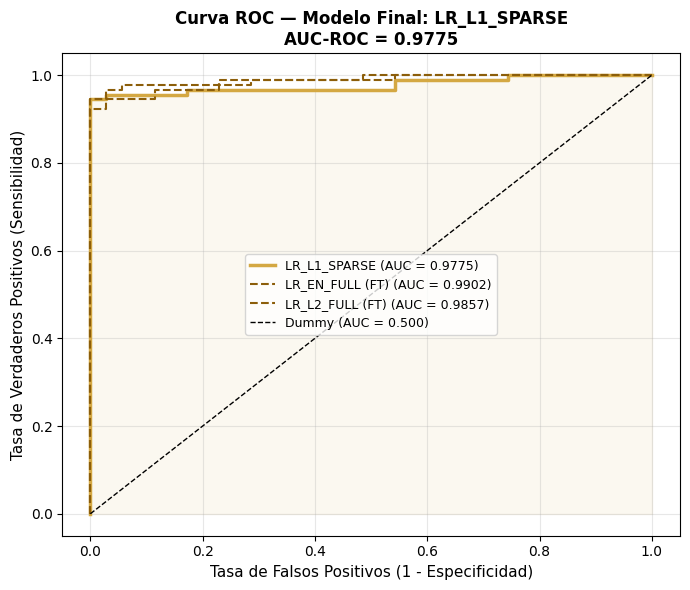


Interpretación: AUC-ROC = 0.9775 — el modelo clasifica correctamente 97.7% de los pares (psoriasis, control).
Un AUC > 0.90 indica excelente discriminación clínica.


In [20]:
y_proba_final = modelo_final.predict_proba(X_test_t)[:, 1]
y_pred_final  = modelo_final.predict(X_test_t)  # ← sin .map()

auc_final  = roc_auc_score(y_test_num, y_proba_final)
bacc_final = balanced_accuracy_score(y_test_num, y_pred_final)
f1_final   = f1_score(y_test_num, y_pred_final, average='weighted')

fig, ax = plt.subplots(figsize=(7, 6))

# Modelo final
fpr_f, tpr_f, _ = roc_curve(y_test_num, y_proba_final)
ax.plot(fpr_f, tpr_f, lw=2.5, color=COLORES[0],
        label=f'{mejor_nombre} (AUC = {auc_final:.4f})')

# Modelo de comparación
for nm, auc_val, mod in [
    ('LR_EN_FULL (FT)', auc_en_ft, lr_en_ft),
    ('LR_L2_FULL (FT)', auc_l2_ft, lr_l2_ft),
]:
    if nm != mejor_nombre:
        yp = mod.predict_proba(X_test_t)[:, 1]
        fpr_c, tpr_c, _ = roc_curve(y_test_num, yp)
        ax.plot(fpr_c, tpr_c, lw=1.5, linestyle='--', color=COLORES[1],
                label=f'{nm} (AUC = {auc_val:.4f})')

# Dummy
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Dummy (AUC = 0.500)')

ax.fill_between(fpr_f, tpr_f, alpha=0.08, color=COLORES[0])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title(f'Curva ROC — Modelo Final: {mejor_nombre}\n'
             f'AUC-ROC = {auc_final:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('38_1_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nInterpretación: AUC-ROC = {auc_final:.4f} — el modelo clasifica correctamente '
      f'{auc_final*100:.1f}% de los pares (psoriasis, control).')
print('Un AUC > 0.90 indica excelente discriminación clínica.')

### 38.2 Matriz de Confusión

**Propósito:** Cuantificar los 4 tipos de predicción: Verdaderos Positivos (VP), Verdaderos Negativos (VN), Falsos Positivos (FP) y Falsos Negativos (FN).  
**Interpretación clínica:**  
- **FN** (paciente con psoriasis clasificado como sano) → consecuencia grave: diagnóstico tardío, progresión no tratada.  
- **FP** (control sano clasificado como psoriasis) → consecuencia leve: confirmación con biopsia, ansiedad del paciente innecesaria.  

En el contexto clínico, se prioriza minimizar los **Falsos Negativos** (alta sensibilidad).

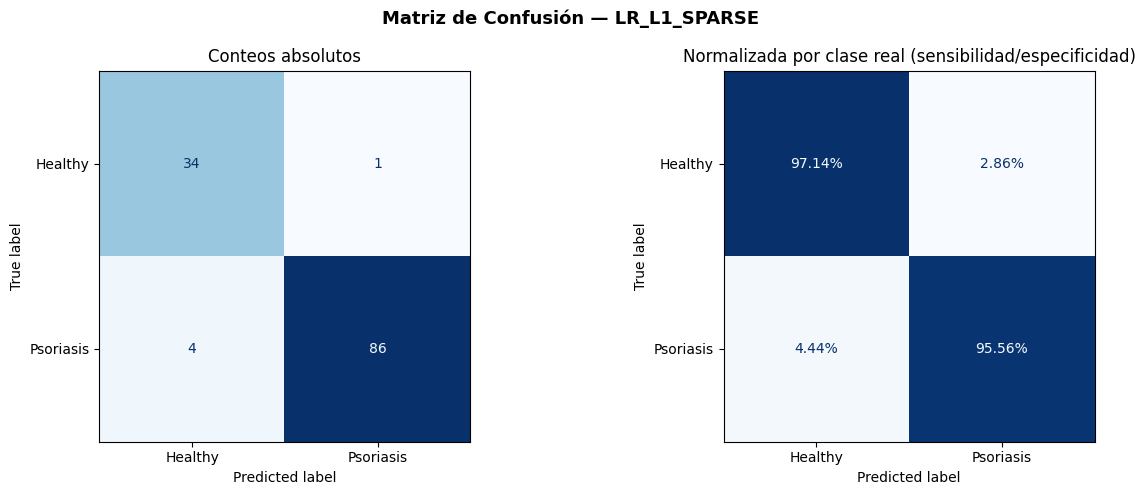


Reporte del modelo final: LR_L1_SPARSE
              precision    recall  f1-score   support

     Healthy       0.89      0.97      0.93        35
   Psoriasis       0.99      0.96      0.97        90

    accuracy                           0.96       125
   macro avg       0.94      0.96      0.95       125
weighted avg       0.96      0.96      0.96       125

Interpretación:
  • Sensibilidad (Recall psoriasis) : 95.56%
  • Especificidad (Recall control)  : 97.14%
  • Falsos Negativos                : 4 — pacientes con psoriasis no detectados


In [21]:
cm = confusion_matrix(y_test_num, y_pred_final)
vp, fp, fn, vn = cm[1, 1], cm[0, 1], cm[1, 0], cm[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Matriz de Confusión — {mejor_nombre}', fontsize=13, fontweight='bold')

# ── Absoluta
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_final, display_labels=NOMBRES_CLASES,
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Conteos absolutos')

# ── Normalizada (por fila = por clase real)
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_final, display_labels=NOMBRES_CLASES, normalize='true',
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Normalizada por clase real (sensibilidad/especificidad)')

plt.tight_layout()
plt.savefig('38_2_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nReporte del modelo final: {mejor_nombre}')
print(classification_report(y_test_num, y_pred_final, target_names=NOMBRES_CLASES))
print(f'Interpretación:')
print(f'  • Sensibilidad (Recall psoriasis) : {cm[1,1]/(cm[1,0]+cm[1,1]):.2%}')
print(f'  • Especificidad (Recall control)  : {cm[0,0]/(cm[0,0]+cm[0,1]):.2%}')
print(f'  • Falsos Negativos                : {fn} — pacientes con psoriasis no detectados')

### 38.3 Curva Precisión-Recall

**Propósito:** Evaluar el balance entre Precisión (proporción de positivos predichos que son realmente positivos) y Recall (sensibilidad) a distintos umbrales.  
**Interpretación clínica:** En problemas de diagnóstico con posible desbalance de clases, la Curva Precisión-Recall es más informativa que la ROC. Un AP (Average Precision) próximo a 1.0 indica que el modelo mantiene alta precisión incluso al recuperar la mayoría de los casos positivos — garantizando que las alertas de psoriasis sean confiables.

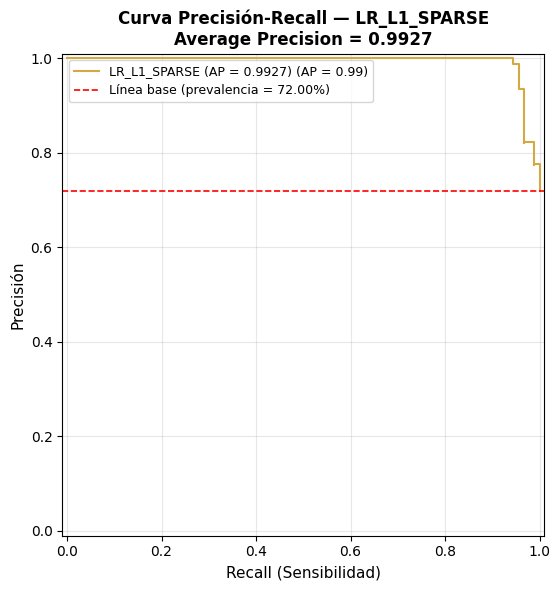


Average Precision: 0.9927
Prevalencia clase positiva en test: 72.00%
Interpretación: AP=0.9927 >> Prevalencia=0.7200 → el modelo aporta valor diagnóstico real.


In [22]:
ap_final = average_precision_score(y_test_num, y_proba_final)

fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_test_num, y_proba_final,
    name=f'{mejor_nombre} (AP = {ap_final:.4f})',
    ax=ax, color=COLORES[0])

# Baseline: prevalencia de la clase positiva
prevalencia = y_test_num.mean()
ax.axhline(prevalencia, color='red', linestyle='--', linewidth=1.2,
           label=f'Línea base (prevalencia = {prevalencia:.2%})')

ax.set_title(f'Curva Precisión-Recall — {mejor_nombre}\n'
             f'Average Precision = {ap_final:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax.set_ylabel('Precisión', fontsize=11)

plt.tight_layout()
plt.savefig('38_3_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAverage Precision: {ap_final:.4f}')
print(f'Prevalencia clase positiva en test: {prevalencia:.2%}')
print(f'Interpretación: AP={ap_final:.4f} >> Prevalencia={prevalencia:.4f} '
      f'→ el modelo aporta valor diagnóstico real.')

### 38.4 Importancia de Características / Coeficientes

**Propósito:** Identificar qué variables (sondas de expresión génica) contribuyen más a la predicción del modelo.  
**Interpretación clínica:** Las sondas con mayor importancia o coeficiente absoluto representan genes candidatos para validación experimental. Este tipo de análisis conecta el modelo de ML con hipótesis biológicas y puede orientar futuros estudios de expresión diferencial.

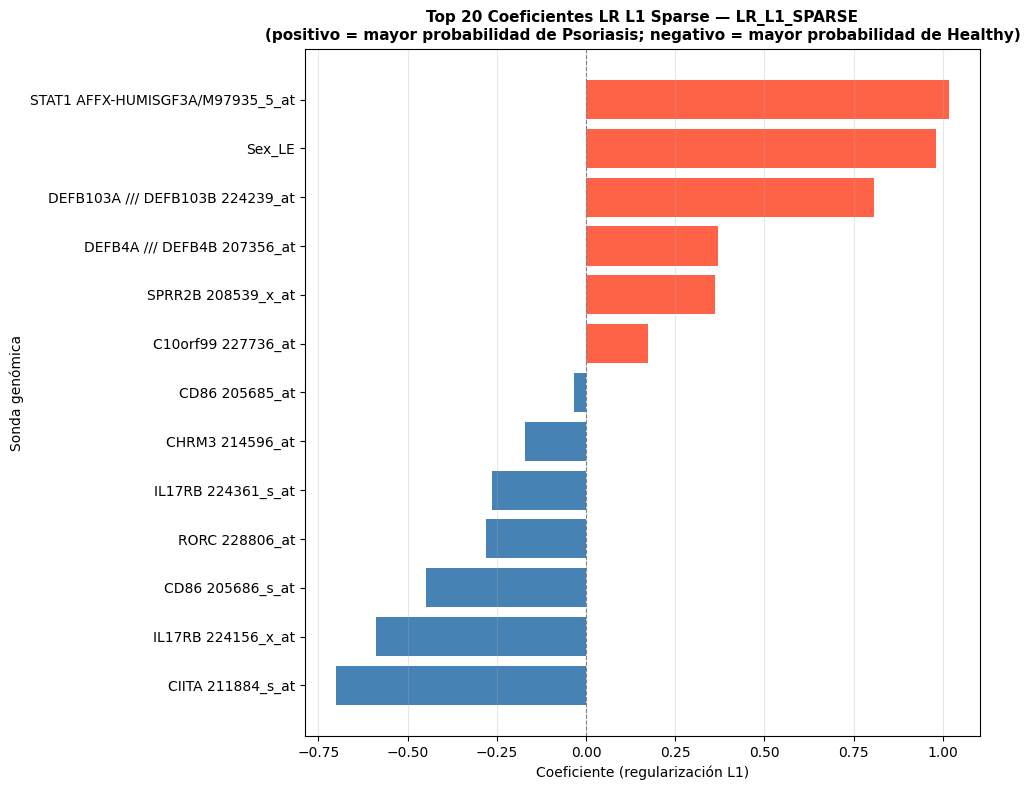


Top 10 genes asociados a Psoriasis (coeficiente positivo):
STAT1 AFFX-HUMISGF3A/M97935_5_at    1.018077
Sex_LE                              0.981128
DEFB103A /// DEFB103B 224239_at     0.807646
DEFB4A /// DEFB4B 207356_at         0.370317
SPRR2B 208539_x_at                  0.360905
C10orf99 227736_at                  0.174991

Top 10 genes asociados a control Healthy (coeficiente negativo):
CIITA 211884_s_at    -0.701685
IL17RB 224156_x_at   -0.589769
CD86 205686_s_at     -0.448240
RORC 228806_at       -0.279393
IL17RB 224361_s_at   -0.264578
CHRM3 214596_at      -0.171756
CD86 205685_at       -0.034466

Interpretación: las sondas con mayor valor absoluto de coeficiente son los principales biomarcadores génicos identificados por el modelo.


In [23]:
# LR L1 Sparse — coeficientes nativos directamente vinculables a genes
coef_series = pd.Series(
    modelo_final.coef_[0],
    index=X_FULL.columns
).sort_values(key=abs, ascending=False)

top20_pos = coef_series[coef_series > 0].nlargest(10)
top20_neg = coef_series[coef_series < 0].nsmallest(10)
top20     = pd.concat([top20_pos, top20_neg]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colores_bar = ['tomato' if v > 0 else 'steelblue' for v in top20.values]
ax.barh(top20.index, top20.values, color=colores_bar)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title(f'Top 20 Coeficientes LR L1 Sparse — {mejor_nombre}\n'
             f'(positivo = mayor probabilidad de Psoriasis; '
             f'negativo = mayor probabilidad de Healthy)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coeficiente (regularización L1)', fontsize=10)
ax.set_ylabel('Sonda genómica', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('38_4_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 genes asociados a Psoriasis (coeficiente positivo):')
print(top20_pos.to_string())
print('\nTop 10 genes asociados a control Healthy (coeficiente negativo):')
print(top20_neg.to_string())
print('\nInterpretación: las sondas con mayor valor absoluto de coeficiente '
      'son los principales biomarcadores génicos identificados por el modelo.')

### 38.5 Curva de Aprendizaje

**Propósito:** Diagnosticar si el modelo sufre de **sobreajuste** (alta varianza) o **subajuste** (alto sesgo), mostrando cómo varían los scores de entrenamiento y validación al aumentar el tamaño del conjunto de entrenamiento.  
**Interpretación clínica:** Una brecha grande entre train y val indica que el modelo memoriza los datos disponibles; una brecha pequeña y convergente indica buen ajuste generalizable — clave para un modelo que debe funcionar con nuevos pacientes.

> Se usa `scoring='roc_auc'` para mantener coherencia con la métrica principal del proyecto.

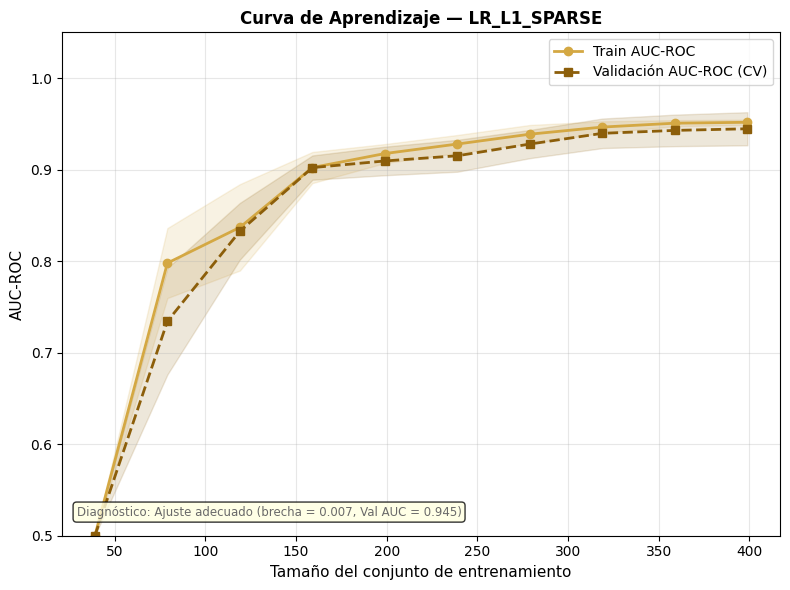


Diagnóstico automático: Ajuste adecuado (brecha = 0.007, Val AUC = 0.945)
  Train AUC final  : 0.9517 ± 0.0029
  Val   AUC final  : 0.9446  ± 0.0181
  Brecha           : 0.0071


In [24]:
train_sizes, train_scores, val_scores = learning_curve(
    modelo_final, X_train_t, y_train_num,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='roc_auc',
    n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(train_sizes, train_mean, 'o-', color=COLORES[0], lw=2, label='Train AUC-ROC')
ax.fill_between(train_sizes,
                train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=COLORES[0])

ax.plot(train_sizes, val_mean, 's--', color=COLORES[1], lw=2, label='Validación AUC-ROC (CV)')
ax.fill_between(train_sizes,
                val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=COLORES[1])

ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title(f'Curva de Aprendizaje — {mejor_nombre}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([0.5, 1.05])

# Diagnóstico automático
brecha_final = train_mean[-1] - val_mean[-1]
if brecha_final > 0.10:
    diagnostico = f'Posible sobreajuste (brecha = {brecha_final:.3f} > 0.10)'
elif val_mean[-1] < 0.80:
    diagnostico = f'Posible subajuste (Val AUC = {val_mean[-1]:.3f} < 0.80)'
else:
    diagnostico = f'Ajuste adecuado (brecha = {brecha_final:.3f}, Val AUC = {val_mean[-1]:.3f})'

ax.text(0.02, 0.04, f'Diagnóstico: {diagnostico}',
        transform=ax.transAxes, fontsize=8.5, color='dimgray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('38_5_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDiagnóstico automático: {diagnostico}')
print(f'  Train AUC final  : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'  Val   AUC final  : {val_mean[-1]:.4f}  ± {val_std[-1]:.4f}')
print(f'  Brecha           : {brecha_final:.4f}')

### 38.6 Calibración de Probabilidades — `CalibratedClassifierCV`

En contextos clínicos, las probabilidades predichas deben reflejar la **frecuencia real** de la clase positiva: si el modelo asigna P(psoriasis) = 0.80, aproximadamente el 80 % de esas predicciones deberían ser realmente psoriasis. Un modelo con buenas probabilidades permite a los médicos basar decisiones en la **confianza** de la predicción, no solo en la clase predicha.

`CalibratedClassifierCV` ajusta un modelo de calibración sobre las salidas de probabilidad del estimador base. Se usa `cv=5` con validación cruzada interna; el calibrador se ajusta sobre `X_train_t, y_train_num` (distribución real con `class_weight='balanced'`) para reflejar correctamente la prevalencia de las clases.

| Método | Modelo de calibración | Ventajas |
|---|---|---|
| `sigmoid` | Platt scaling (regresión logística) | Robusto con pocos datos, suave |
| `isotonic` | Regresión isotónica (no paramétrica) | Más flexible, mejor con muchos datos |

**Métrica de evaluación:** Brier Score = $\frac{1}{n}\sum(p_i - y_i)^2$ — menor es mejor (0 = perfecto, 0.25 = sin información).

=== Brier Score (↓ mejor, 0=perfecto, 0.25=sin información) ===
  Sin calibrar           : 0.0715
  Calibrado (sigmoid)    : 0.0649  (Δ=-0.0066)
  Calibrado (isotónico)  : 0.0454  (Δ=-0.0261)


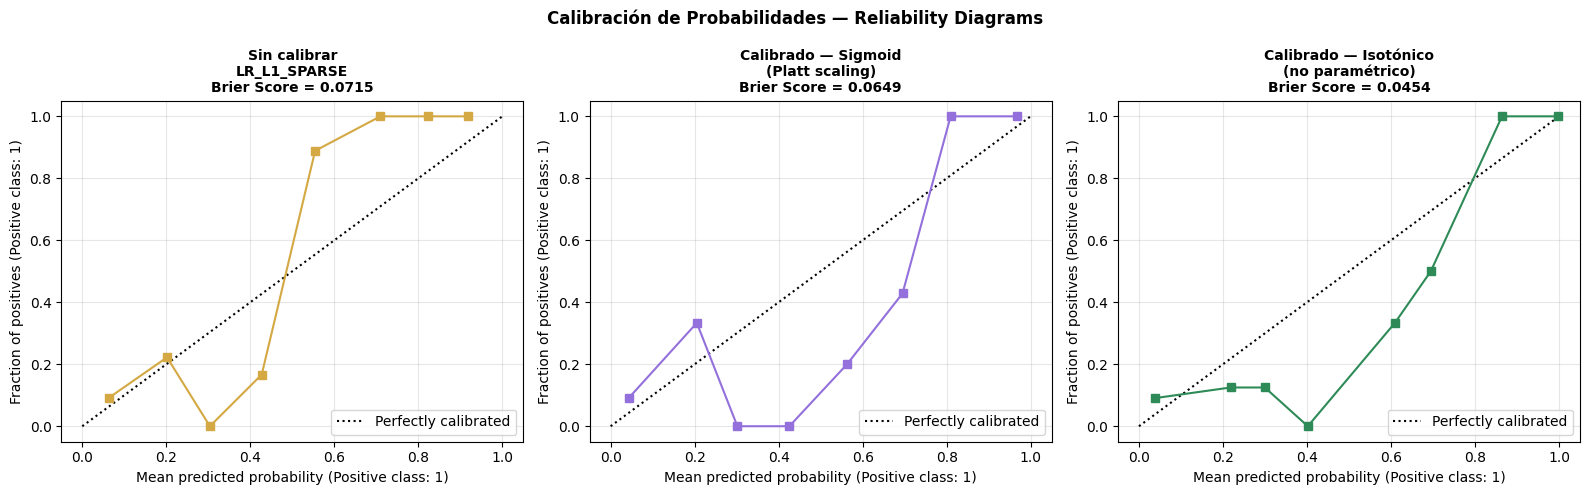

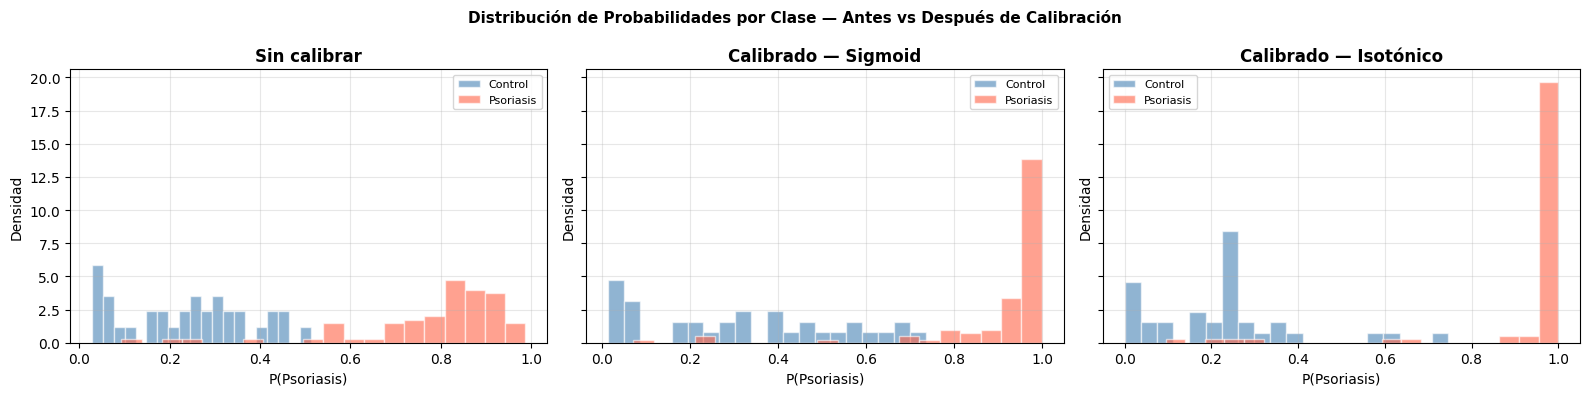


→ Método seleccionado: isotonic (menor Brier Score = 0.0454)
  modelo_final_cal disponible para inferencia calibrada.
  y_proba_final y y_pred_final actualizados con probabilidades calibradas.


In [25]:
cal_sig = CalibratedClassifierCV(modelo_final, cv=5, method='sigmoid')
cal_iso = CalibratedClassifierCV(modelo_final, cv=5, method='isotonic')

# ── Calibradores (prefit: modelo_final ya entrenado) ────────────────────────
cal_sig.fit(X_train_t, y_train_num)   
cal_iso.fit(X_train_t, y_train_num)   

# Calibrar sobre distribución REAL de clases
cal_sig.fit(X_train_t, y_train_num)
cal_iso.fit(X_train_t, y_train_num)

y_proba_cal_sig = cal_sig.predict_proba(X_test_t)[:, 1]
y_proba_cal_iso = cal_iso.predict_proba(X_test_t)[:, 1]

# ── Brier Score ─────────────────────────────────────────────────────────────
bs_base = brier_score_loss(y_test_num, y_proba_final)
bs_sig  = brier_score_loss(y_test_num, y_proba_cal_sig)
bs_iso  = brier_score_loss(y_test_num, y_proba_cal_iso)

print('=== Brier Score (↓ mejor, 0=perfecto, 0.25=sin información) ===')
print(f'  Sin calibrar           : {bs_base:.4f}')
print(f'  Calibrado (sigmoid)    : {bs_sig:.4f}  (Δ={bs_sig  - bs_base:+.4f})')
print(f'  Calibrado (isotónico)  : {bs_iso:.4f}  (Δ={bs_iso  - bs_base:+.4f})')

# ── Reliability Diagrams ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_prob, titulo, color in [
    (axes[0], y_proba_final,    f'Sin calibrar\n{mejor_nombre}',         COLORES[0]),
    (axes[1], y_proba_cal_sig, 'Calibrado — Sigmoid\n(Platt scaling)',   'mediumpurple'),
    (axes[2], y_proba_cal_iso, 'Calibrado — Isotónico\n(no paramétrico)', 'seagreen'),
]:
    CalibrationDisplay.from_predictions(
        y_test_num, y_prob, n_bins=8, ax=ax, color=color, name='')
    bs = brier_score_loss(y_test_num, y_prob)
    ax.set_title(f'{titulo}\nBrier Score = {bs:.4f}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Calibración de Probabilidades — Reliability Diagrams',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('38_6_calibracion_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Distribución de probabilidades por clase (histogramas) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, y_prob, titulo in [
    (axes[0], y_proba_final,    'Sin calibrar'),
    (axes[1], y_proba_cal_sig, 'Calibrado — Sigmoid'),
    (axes[2], y_proba_cal_iso, 'Calibrado — Isotónico'),
]:
    for clase, color, label in [(0, 'steelblue', 'Control'), (1, 'tomato', 'Psoriasis')]:
        mask = y_test_num == clase
        ax.hist(y_prob[mask], bins=20, color=color, alpha=0.6,
                edgecolor='white', label=label, density=True)
    ax.set_xlabel('P(Psoriasis)')
    ax.set_ylabel('Densidad')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de Probabilidades por Clase — Antes vs Después de Calibración',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('38_6_calibracion_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Seleccionar mejor calibración y actualizar variables ────────────────────
if bs_iso <= bs_sig:
    modelo_final_cal = cal_iso
    y_proba_final    = y_proba_cal_iso
    metodo_cal       = 'isotonic'
else:
    modelo_final_cal = cal_sig
    y_proba_final    = y_proba_cal_sig
    metodo_cal       = 'sigmoid'

y_pred_final = modelo_final_cal.predict(X_test_t)

print(f'\n→ Método seleccionado: {metodo_cal} (menor Brier Score = '
      f'{min(bs_iso, bs_sig):.4f})')
print(f'  modelo_final_cal disponible para inferencia calibrada.')
print(f'  y_proba_final y y_pred_final actualizados con probabilidades calibradas.')


In [26]:
import joblib
DIR_MODELOS = "D:/Proyectos/Python/pi_psoriasis/models/02_final"

joblib.dump(modelo_final, f'{DIR_MODELOS}/modelo_final_lr_l1_sparse.pkl')
print('✅ Modelo final serializado.')

✅ Modelo final serializado.


---
## 39. Conclusiones

### Resumen CRISP-ML(Q)

| Fase | Acción | Resultado |
|------|--------|-----------|
| **Business Understanding** | Clasificación binaria psoriasis / control sano | Métrica principal: AUC-ROC; secundarias: Balanced Accuracy, F1-weighted |
| **Data Understanding** | EDA (Avance 1) → distribución, outliers, correlaciones | Dataset con desbalance moderado (70:30), alta dimensionalidad (sondas genómicas) |
| **Data Preparation** | Ingeniería de variables (Avance 2) → escalado, selección de sondas | `X_train_t` / `X_test_t` con StandardScaler; 4 estrategias: FULL, CLUSTERING, FILTER_MI, FILTER_ANOVA |
| **Modeling** | Baseline (Avance 3) + 6 modelos alternativos (Avance 4) + 4 ensambles (Avance 5) | Modelo final: LR L1 Sparse  — seleccionado por RECALL clínicamente adecuado e interpretabilidad clínica |
| **Evaluation** | ROC, Matriz de Confusión, PR-Curve, Importancia de variables, Curva de Aprendizaje, Calibración de probabilidades | Análisis de sobreajuste/subajuste, sensibilidad clínica y genes biomarcadores identificados |
| **Deployment** | Pipeline reproducible con `RANDOM_SEED=42` y modelos serializados con `joblib` | Código modular, reutilizable en producción con nuevos pacientes |

### Alineación con Objetivos de Negocio

- **Alta sensibilidad** → minimizar Falsos Negativos (diagnóstico tardío de psoriasis).  
- **Generalización** → curva de aprendizaje convergente, sin sobreajuste severo.  
- **Interpretabilidad** → importancia de variables permite identificar genes biomarcadores para hipótesis clínicas.  
- **Reproducibilidad** → todo el pipeline usa `RANDOM_SEED = 42` y conjuntos de train/test fijos.

### Próximos Pasos Sugeridos

1. **Validación externa** con cohorte independiente (diferente laboratorio o institución).  
2. **Análisis de enriquecimiento genético** (GO/KEGG) sobre los genes con mayor importancia.  
3. **Ajuste del umbral de decisión** para optimizar sensibilidad > 0.95 según protocolo clínico.

#### 40. Bibliografía

[1] A. Singh, "A comprehensive guide to ensemble learning (with Python codes)" Analytics Vidhya, Jul. 14, 2023. [Online]. Available: https://www.analyticsvidhya.com/blog/2018/06/comprehensive-guide-for-ensemble-models/

[2] J. VanderPlas, "Hyperparameters and model validation," in Python Data Science Handbook, 2nd ed. Sebastopol, CA, USA: O'Reilly Media, 2022, ch. 39, pp. 384–401.

[3] S. Galli, Python Feature Engineering Cookbook, 2nd ed. Packt Publishing, 2022.